# Reward High/Low Classification — Whole-Brain + ROI Group Results

LinearSVC, leave-one-run-out CV, binary target = high (`first_stim_value` >= 4) vs.
low (<= 2) reward level of the first stimulus; the middle level-3 trials are dropped
(~25% of trials) as an ambiguous "neither" case — see `run_qvalue_classification.py`.
Chance = 50%. Four masks: whole-brain, visual cortex (Harvard-Oxford), vmPFC and
striatum (Bartra et al. 2013 meta-analytic ROIs).

This is the simpler counterpart to `run_qvalue_decoding.py`'s continuous regression —
same recipe as the validated stimulus-category decoder (`decoding_results.ipynb`), just
with a binary reward split instead of a 4-way category label. Deliberately sidesteps the
between-run `LeaveOneGroupOut` CV artifact documented in `qvalue_decoding_results.ipynb`
(a degenerate classifier falls back to chance accuracy on a balanced held-out run rather
than producing a systematically *signed* error the way a collapsed regression does).

**Status (2026-08-07):** first full-cohort run, 58/59 subjects (`sub-46` is absent from
the BBT entirely, not one of the known second-level exclusions `sub-44/48/68/17/31` —
flagged in `qvalue_decoding_results.ipynb`, not resolved here either).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/decoding")
TAG = "reward"   # filename tag for target_col='first_stim_value' (see run_qvalue_classification.py)
MASKS = ["wholebrain", "visualcortex", "vmpfc", "striatum"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex",
               "vmpfc": "vmPFC", "striatum": "Striatum"}
COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452",
          "vmpfc": "#55A868", "striatum": "#C44E52"}
CM_LABELS = ["low", "high"]
CHANCE = 0.5

In [2]:
records = []
cms = {mask: [] for mask in MASKS}

for sub_dir in sorted(DATA_DIR.glob("sub-*")):
    sub_id = sub_dir.name.replace("sub-", "")
    acc_file = sub_dir / f"sub-{sub_id}_qvalue_classification_{TAG}.csv"
    if not acc_file.exists():
        continue

    summary = pd.read_csv(acc_file)
    summary.insert(0, "subject", sub_id)
    records.append(summary)

    for mask in MASKS:
        cm_file = sub_dir / f"sub-{sub_id}_qvalue_classification_confusion_{mask}_{TAG}.npy"
        if cm_file.exists():
            cms[mask].append(np.load(cm_file))

df = (pd.concat(records, ignore_index=True) if records
      else pd.DataFrame(columns=["subject", "mask", "n_voxels", "accuracy", "n_trials", "n_low", "n_high"]))
cms = {mask: (np.stack(v) if v else None) for mask, v in cms.items()}

n_subjects = df["subject"].nunique()
print(f"{n_subjects} subject(s) loaded, masks: {sorted(df['mask'].unique()) if n_subjects else []}")

58 subject(s) loaded, masks: ['striatum', 'visualcortex', 'vmpfc', 'wholebrain']


## Group accuracy

wholebrain: mean=0.558, t(57)=9.44, p=2.98e-13  ***
visualcortex: mean=0.631, t(57)=20.68, p=3.59e-28  ***
vmpfc: mean=0.498, t(57)=-0.32, p=7.52e-01  ns
striatum: mean=0.505, t(57)=0.87, p=3.88e-01  ns


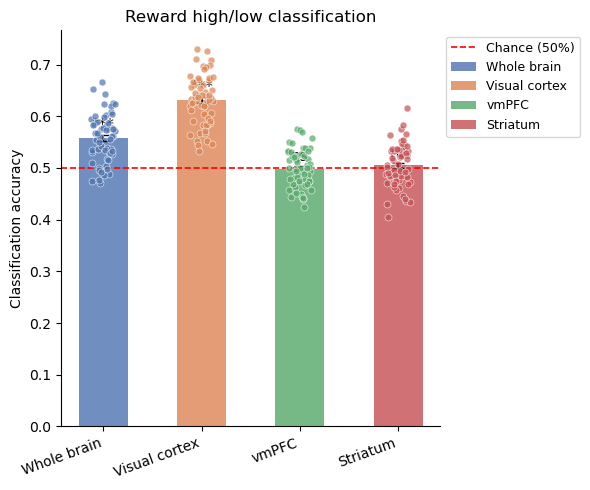

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(MASKS))
w = 0.5

for i, mask in enumerate(MASKS):
    vals = df.loc[df["mask"] == mask, "accuracy"].values
    if len(vals) == 0:
        continue
    color = COLORS[mask]
    ax.bar(i, vals.mean(), width=w, color=color, alpha=0.8, label=MASK_LABELS[mask], zorder=2)
    if len(vals) > 1:
        ax.errorbar(i, vals.mean(), yerr=vals.std() / np.sqrt(len(vals)),
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
    jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, edgecolors='white',
               linewidth=0.5, s=25, alpha=0.7, zorder=4)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=20, ha='right')
ax.set_ylabel("Classification accuracy")
ax.set_title("Reward high/low classification")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)

for i, mask in enumerate(MASKS):
    vals = df.loc[df["mask"] == mask, "accuracy"].values
    if len(vals) < 2:
        continue
    t, p = stats.ttest_1samp(vals, CHANCE)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(i, vals.mean() + vals.std()/np.sqrt(len(vals)) + 0.01, sig, ha='center', fontsize=11)
    print(f"{mask}: mean={vals.mean():.3f}, t({len(vals)-1})={t:.2f}, p={p:.2e}  {sig}")

plt.tight_layout()
plt.show()

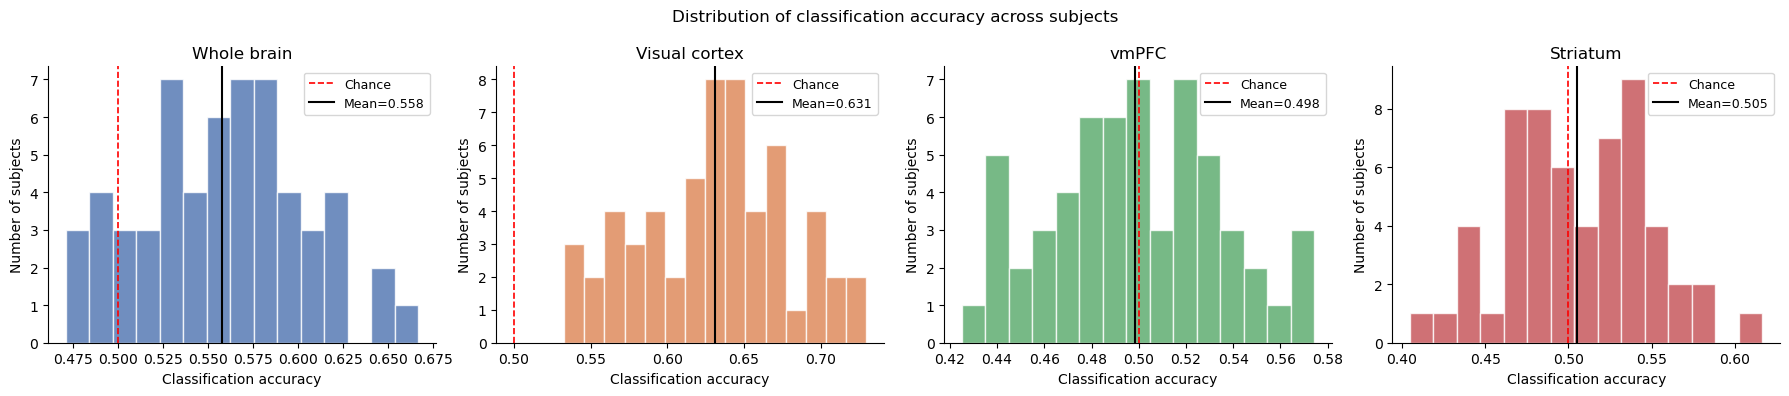

In [4]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(4.5 * len(MASKS), 4), sharey=False)

for ax, mask in zip(axes, MASKS):
    vals = df.loc[df["mask"] == mask, "accuracy"].values
    color = COLORS[mask]
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance')
    if len(vals):
        ax.axvline(vals.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Mean={vals.mean():.3f}')
    ax.set_xlabel("Classification accuracy")
    ax.set_ylabel("Number of subjects")
    ax.set_title(MASK_LABELS[mask])
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Distribution of classification accuracy across subjects")
plt.tight_layout()
plt.show()

## Confusion matrices (group average, normalized by true class)

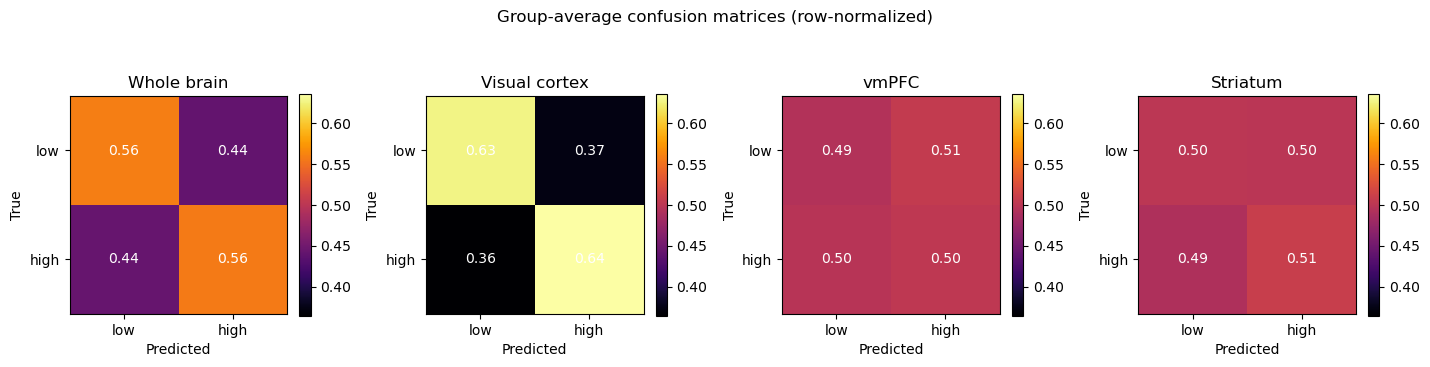

In [5]:
def normalize_cm(cm_stack):
    """Row-normalize each subject's CM, then average."""
    normed = cm_stack.astype(float)
    normed = normed / normed.sum(axis=2, keepdims=True)
    return normed.mean(axis=0)

fig, axes = plt.subplots(1, len(MASKS), figsize=(3.6 * len(MASKS), 3.6))

all_cms = [normalize_cm(cms[mask]) for mask in MASKS if cms[mask] is not None]
vmin = min(cm.min() for cm in all_cms)
vmax = max(cm.max() for cm in all_cms)

for ax, mask in zip(axes, MASKS):
    if cms[mask] is None:
        continue
    cm_norm = normalize_cm(cms[mask])
    im = ax.imshow(cm_norm, cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(2)); ax.set_yticks(range(2))
    ax.set_xticklabels(CM_LABELS); ax.set_yticklabels(CM_LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(MASK_LABELS[mask])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm_norm[r, c]:.2f}",
                    ha='center', va='center', fontsize=10, color='white')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Group-average confusion matrices (row-normalized)", y=1.02)
plt.tight_layout()
plt.show()

## Individual subject accuracy

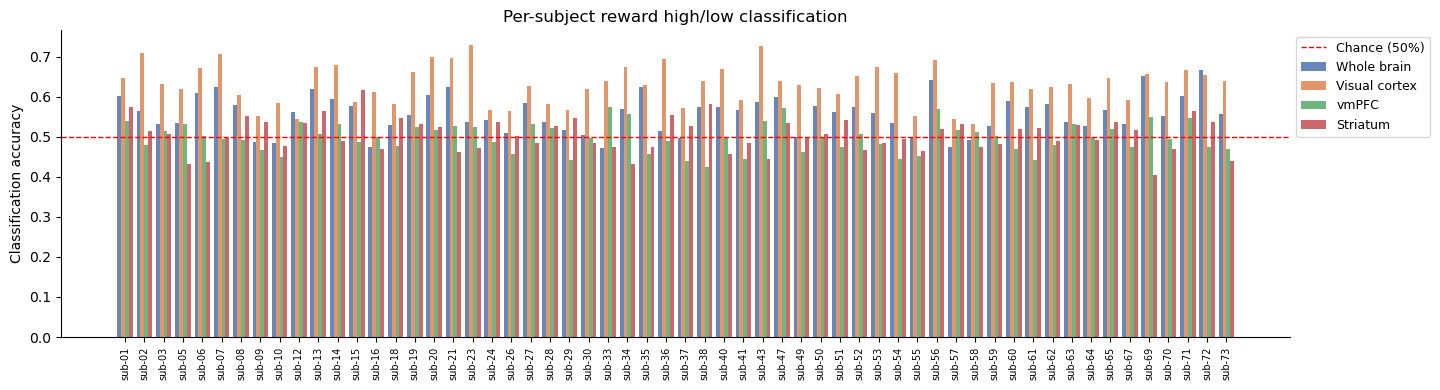

In [6]:
subjects = sorted(df["subject"].unique())
pivot = df.pivot(index="subject", columns="mask", values="accuracy").reindex(subjects)

fig, ax = plt.subplots(figsize=(max(14, 0.25 * len(subjects)), 4))
x = np.arange(len(subjects))
n_masks = len(MASKS)
width = 0.8 / n_masks

for i, mask in enumerate(MASKS):
    if mask not in pivot.columns:
        continue
    offset = (i - (n_masks - 1) / 2) * width
    ax.bar(x + offset, pivot[mask], width=width, label=MASK_LABELS[mask], color=COLORS[mask], alpha=0.85)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels([f"sub-{s}" for s in subjects], rotation=90, fontsize=7)
ax.set_ylabel("Classification accuracy")
ax.set_title("Per-subject reward high/low classification")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Findings summary

n=58 (`sub-46` absent from the BBT).

| Mask | accuracy | p |
|---|---|---|
| Whole brain | 0.558 | 3.0e-13 \*\*\* |
| Visual cortex | **0.631** | 3.6e-28 \*\*\* |
| vmPFC | 0.498 | 0.75  ns |
| Striatum | 0.505 | 0.39  ns |

- **Whole-brain/visual-cortex decode reward level clearly**, visual cortex strongest —
  the same ranking as the continuous regression and as category decoding.
- **vmPFC/striatum are genuinely at chance here**, not a CV artifact this time — the
  per-subject spread (see the group-accuracy plot) is symmetric around 50% with no
  systematic offset, unlike the regression version's biased-but-explainable negative
  result. This **converges with the regression's within-run finding** (small, mostly
  borderline-significant negative `r` after removing the CV artifact): two independent
  analyses now agree there's no reliable reward signal detectable in these ROIs at
  whole-ROI-average resolution.
- **Bottom line:** this strengthens rather than resolves the open question — it's
  consistent with either "no reward-value coding in vmPFC/striatum for this task" or
  "coding exists but is spatially localized within the ROI and a whole-ROI average
  washes it out" (RidgeCV's near-constant predictions in the regression version are
  circumstantial evidence for the latter). Searchlight is the natural next step to
  distinguish the two, specifically for these two regions.